In [250]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [251]:
df = pd.read_csv("istanbulApartmentForRent.csv")

In [252]:
df = df[df["area (m2)"]<400]
df = df[df["price"]<500000]



df = df[df["price"] > 5000]
df = df[df["area (m2)"] > 0]

df = df.dropna()

<Axes: xlabel='area (m2)', ylabel='price'>

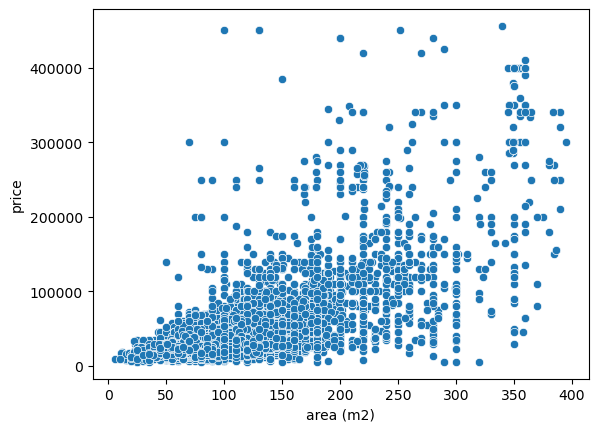

In [253]:
sns.scatterplot(data=df,x="area (m2)",y="price")


In [254]:
x = df[["area (m2)","age","room"]]
y = df["price"]

x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [255]:
'''model = LinearRegression()
model.fit(x_train,y_train)

skor = model.score(x_test,y_test)
print(f"Model success rate:{skor:.4f}")'''

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

skor = model.score(x_test, y_test)
print(f"Random Forest success rate: {skor:.4f}")

Random Forest success rate: 0.6051


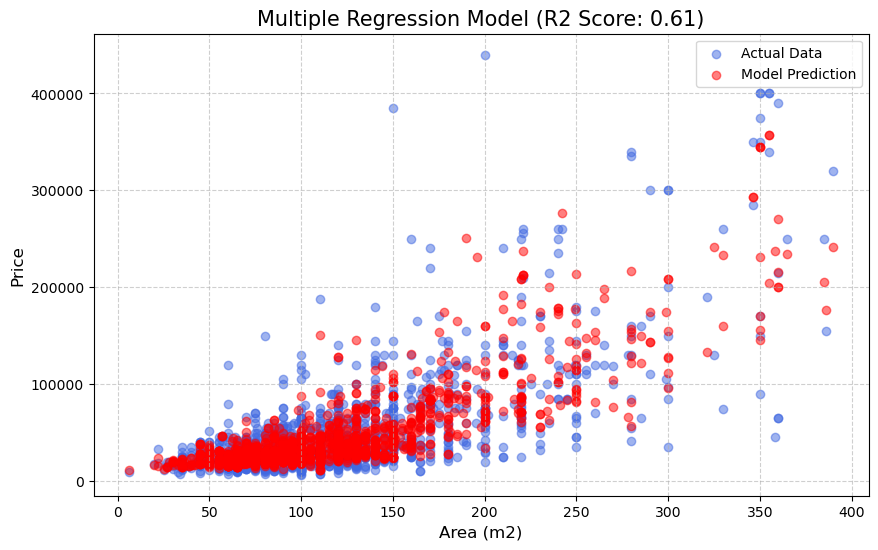

In [256]:
plt.figure(figsize=(10, 6))

# x_test içinden sadece 'area (m2)' sütununu seçiyoruz
plt.scatter(x_test['area (m2)'], y_test, color='royalblue', alpha=0.5, label='Actual Data')

# Tahmin yaparken model tüm x_test'i (3 sütunu) kullanmaya devam ediyor
plt.scatter(x_test['area (m2)'], model.predict(x_test), color='red', alpha=0.5, label='Model Prediction')

plt.title(f'Multiple Regression Model (R2 Score: {skor:.2f})', fontsize=15)
plt.xlabel('Area (m2)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [257]:
test_data = pd.DataFrame([[150, 13, 3]], columns=["area (m2)", "age", "room"])
prediction = model.predict(test_data)

print(f"Prediction {prediction[0]:,.2f}")

Prediction 46,124.77
